<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ%20Uzmanl%C4%B1%C4%9F%C4%B1-5B2C1E?style=for-the-badge&logo=python&logoColor=white" alt="ECS VB&YZ 90"/>

# Hafta 8: Ek: Askeri Guc Kumeleme

**MAKİNE ÖĞRENMESİ UZMANLIĞI** · Modül 8 · 6 Saat

---

<a href="https://colab.research.google.com/github/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta08/ek_askeri_guc_kumeleme.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colab'da Aç"/></a>&nbsp;
<a href="https://github.com/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta08/ek_askeri_guc_kumeleme.ipynb"><img src="https://img.shields.io/badge/GitHub'da%20A%C3%A7-181717?style=flat&logo=github&logoColor=white" alt="GitHub'da Aç"/></a>

</div>

# World Military Power Clustering

Bu proje, ülkeleri askeri kabiliyetleri ve güçleri temelinde gruplandırarak askeri güç açısından benzer desenleri, ittifakları ve bölgesel üstünlükleri belirlemeyi amaçlamaktadır. Savunma bütçesi, aktif askeri personel sayısı, tank sayısı, uçak sayısı, deniz gemileri, füze sistemleri ve diğer askeri varlıklar gibi faktörlerin dikkate alınması planlanmaktadır. Ayrıca askeri teknoloji, araştırma ve geliştirme faaliyetleri ile hava kuvvetleri gücü gibi faktörler de analiz edilecektir. Bu proje, ülkelerin askeri güçlerini anlamak, benzerlikleri, farklılıkları ve ilişkileri ortaya çıkarmak için kapsamlı bir analiz sunmayı hedeflemektedir.

## Importing libraries

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `matplotlib` | Görselleştirme |
| `numpy` | Sayısal hesaplamalar |
| `pandas` | Veri analizi |
| `scipy` | Bilimsel hesaplama |
| `seaborn` | İstatistiksel grafikler |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `warnings` | Uyarı yönetimi |


In [ ]:
import warnings
warnings.filterwarnings('ignore')
warnings.warn('Uyarılar gizlendi!')
%matplotlib inline

In [ ]:
plt.rcParams['figure.figsize']=(10,6)
plt.rcParams['figure.dpi'] = 100

sns.set_style("darkgrid")
pd.set_option('display.float_format', lambda x: '%.3f' % x)

pd.options.display.max_rows = 1000
pd.options.display.max_columns = 150

#### Read Data

### pip install openpyxl

In [ ]:
#pip install openpyxl

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `google` | Google API |


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path= '/content/drive/MyDrive/Bootcamp_projeler/Assingments/12- World military power/World military power.xlsx'

In [ ]:
df=pd.read_excel(file_path,header=[0,1])
df.head()

2020 ranking                               Airforce Strength  \
  Military Strength Military Strength Power Index Aircraft Strength   
0       Afghanistan                         1.344       Afghanistan   
1           Albania                         2.314           Albania   
2           Algeria                         0.466           Algeria   
3            Angola                         0.838            Angola   
4         Argentina                         0.652         Argentina   

                                                        \
  Aircraft Strength value Fighter/Interceptor Strength   
0                     260                  Afghanistan   
1                      19                      Albania   
2                     551                      Algeria   
3                     295                       Angola   
4                     227                    Argentina   

                                                               \
  Fighter/Interceptor Strength value Attack Aircraft Strength   
0                                  0              Afghanistan   
1                                  0                  Albania   
2                                103                  Algeria   
3                                 72                   Angola   
4                                 24                Argentina   

                                                                    \
  Attack Aircraft Strength value Transport Aircraft Fleet Strength   
0                             25                       Afghanistan   
1                              0                           Albania   
2                             22                           Algeria   
3                             18                            Angola   
4                              7                         Argentina   

                                                                  \
  Transport Aircraft Fleet Strength value Trainer Aircraft Fleet   
0                                      30            Afghanistan   
1                                       0                Albania   
2                                      59                Algeria   
3                                      30                 Angola   
4                                       9              Argentina   

                                                          \
  Trainer Aircraft Fleet value Helicopter Fleet Strength   
0                            0               Afghanistan   
1                            0                   Albania   
2                           87                   Algeria   
3                           47                    Angola   
4                           64                 Argentina   

                                                                    \
  Helicopter Fleet Strength value Attack Helicopter Fleet Strength   
0                             187                      Afghanistan   
1                              19                          Albania   
2                             257                          Algeria   
3                             126                           Angola   
4                             100                        Argentina   

                                         Land Strength                      \
  Attack Helicopter Fleet Strength value Tank Strength Tank Strength value   
0                                      0   Afghanistan                   0   
1                                      0       Albania                   0   
2                                     45       Algeria                 880   
3                                     15        Angola                 379   
4                                      0     Argentina                 370   

                                                                             \
  AFV/APC Strength AFV/APC Strength value Self-Propelled Artillery Strength   
0      Afghanistan                   1062                    

In [ ]:
df.columns

MultiIndex([(     '2020 ranking',                       'Military Strength'),
            (     '2020 ranking',           'Military Strength Power Index'),
            ('Airforce Strength',                       'Aircraft Strength'),
            ('Airforce Strength',                 'Aircraft Strength value'),
            ('Airforce Strength',            'Fighter/Interceptor Strength'),
            ('Airforce Strength',      'Fighter/Interceptor Strength value'),
            ('Airforce Strength',                'Attack Aircraft Strength'),
            ('Airforce Strength',          'Attack Aircraft Strength value'),
            ('Airforce Strength',       'Transport Aircraft Fleet Strength'),
            ('Airforce Strength', 'Transport Aircraft Fleet Strength value'),
            ('Airforce Strength',                  'Trainer Aircraft Fleet'),
            ('Airforce Strength',            'Trainer Aircraft Fleet value'),
            ('Airforce Strength',               'Helicopter Flee

### sütunları tek seviyeli hale getir

In [ ]:
#sütunları tek seviyeli hale getir
df.columns = ['_'.join(i) for i in df.columns.values]
df.columns

Index(['2020 ranking_Military Strength',
       '2020 ranking_Military Strength Power Index',
       'Airforce Strength_Aircraft Strength',
       'Airforce Strength_Aircraft Strength value',
       'Airforce Strength_Fighter/Interceptor Strength',
       'Airforce Strength_Fighter/Interceptor Strength value',
       'Airforce Strength_Attack Aircraft Strength',
       'Airforce Strength_Attack Aircraft Strength value',
       'Airforce Strength_Transport Aircraft Fleet Strength',
       'Airforce Strength_Transport Aircraft Fleet Strength value',
       'Airforce Strength_Trainer Aircraft Fleet',
       'Airforce Strength_Trainer Aircraft Fleet value',
       'Airforce Strength_Helicopter Fleet Strength',
       'Airforce Strength_Helicopter Fleet Strength value',
       'Airforce Strength_Attack Helicopter Fleet Strength',
       'Airforce Strength_Attack Helicopter Fleet Strength value',
       'Land Strength_Tank Strength', 'Land Strength_Tank Strength value',
       'Land Strength

# EDA

In [ ]:
df.shape

(138, 60)

### Temel İstatistikler

Verinin yapısını, eksik değerleri ve temel istatistikleri inceliyoruz.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 60 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   2020 ranking_Military Strength                             138 non-null    object 
 1   2020 ranking_Military Strength Power Index                 138 non-null    float64
 2   Airforce Strength_Aircraft Strength                        138 non-null    object 
 3   Airforce Strength_Aircraft Strength value                  138 non-null    int64  
 4   Airforce Strength_Fighter/Interceptor Strength             138 non-null    object 
 5   Airforce Strength_Fighter/Interceptor Strength value       138 non-null    int64  
 6   Airforce Strength_Attack Aircraft Strength                 138 non-null    object 
 7   Airforce Strength_Attack Aircraft Strength value           138 non-null    int64  
 8   Airforce S

In [ ]:
df.head()

,2020 ranking_Military Strength,2020 ranking_Military Strength Power Index,Airforce Strength_Aircraft Strength,Airforce Strength_Aircraft Strength value,Airforce Strength_Fighter/Interceptor Strength,Airforce Strength_Fighter/Interceptor Strength value,Airforce Strength_Attack Aircraft Strength,Airforce Strength_Attack Aircraft Strength value,Airforce Strength_Transport Aircraft Fleet Strength,Airforce Strength_Transport Aircraft Fleet Strength value,Airforce Strength_Trainer Aircraft Fleet,Airforce Strength_Trainer Aircraft Fleet value,Airforce Strength_Helicopter Fleet Strength,Airforce Strength_Helicopter Fleet Strength value,Airforce Strength_Attack Helicopter Fleet Strength,Airforce Strength_Attack Helicopter Fleet Strength value,Land Strength_Tank Strength,Land Strength_Tank Strength value,Land Strength_AFV/APC Strength,Land Strength_AFV/APC Strength value,Land Strength_Self-Propelled Artillery Strength,Land Strength_Self-Propelled Artillery Strength value,Land Strength_Towed Artillery Strength,Land Strength_Towed Artillery Strength value,Land Strength_Rocket Projector Strength,Land Strength_Rocket Projector Strength value,Navy Strength_Navy Fleet Strengths,Navy Strength_Navy Fleet Strengths value,Navy Strength_Aircraft Carrier Fleet Strength,Navy Strength_Aircraft Carrier Fleet Strength value,Navy Strength_Submarine Fleet Strength,Navy Strength_Submarine Fleet Strength value,Navy Strength_Destroyer Fleet Strength,Navy Strength_Destroyer Fleet Strength value,Navy Strength_Frigate Fleet Strength,Navy Strength_Frigate Fleet Strength value,Finances_defense spending budget,Finances_defense spending budget value,Finances_External Debt,Finances_External Debt value,Logistics_Airport Totals,Logistics_Airport Totals value,Natural resources_Oil Production,Natural resources_Oil Production value,Natural resources_Oil Consumption,Natural resources_Oil Consumption value,Natural resources_Proven Oil Reserves,Natural resources_Proven Oil Reserves value,Manpower_Available Manpower,Manpower_Available Manpower value,Manpower_Total Population,Manpower_Total Population value,Geography_Total Square Land Area,Geography_Total Square Land Area value,Geography_Total Coastline Coverage,Geography_Total Coastline Coverage value,Geography_Total Waterway Coverage,Geography_Total Waterway Coverage value,Geography_Total Border Coverage,Geography_Total Border Coverage value
0,Afghanistan,1.344,Afghanistan,260,Afghanistan,0,Afghanistan,25,Afghanistan,30,Afghanistan,0,Afghanistan,187,Afghanistan,0,Afghanistan,0,Afghanistan,1062,Afghanistan,0,Afghanistan,176,Afghanistan,50,Afghanistan,0.000,Afghanistan,0.000,Afghanistan,0.000,Afghanistan,0.000,Afghanistan,0.000,Afghanistan,"12,00,00,00,000",Afghanistan,"2,84,00,00,000",Afghanistan,43,Afghanistan,0,Afghanistan,5500,Afghanistan,0,Afghanistan,"1,43,25,743",Afghanistan,"3,49,40,837",Afghanistan,"6,52,230",Afghanistan,0,Afghanistan,1200,Afghanistan,5987.000
1,Albania,2.314,Albania,19,Albania,0,Albania,0,Albania,0,Albania,0,Albania,19,Albania,0,Albania,0,Albania,467,Albania,0,Albania,0,Albania,0,Albania,38.000,Albania,0.000,Albania,0.000,Albania,0.000,Albania,0.000,Albania,"25,00,00,000",Albania,"9,50,50,00,000",Albania,4,Albania,16000,Albania,42500,Albania,"16,83,00,000",Albania,"15,19,438",Albania,"30,57,220",Albania,28748,Albania,362,Albania,41,Albania,691.000
2,Algeria,0.466,Algeria,551,Algeria,103,Algeria,22,Algeria,59,Algeria,87,Algeria,257,Algeria,45,Algeria,880,Algeria,7361,Algeria,320,Algeria,240,Algeria,316,Algeria,201.000,Algeria,0.000,Algeria,6.000,Algeria,0.000,Algeria,5.000,Algeria,"13,00,00,00,000",Algeria,"6,26,00,00,000",Algeria,157,Algeria,"13,06,000",Algeria,"3,25,000",Algeria,"12,20,00,00,000",Algeria,"2,07,41,263",Algeria,"4,16,57,488",Algeria,"23,81,741",Algeria,998,Algeria,0,Algeria,6734.000
3,Angola,0.838,Angola,295,Angola,72,Angola,18,Angola,30,Angola,47,Angola,126,Angola,15,Angola,379,Angola,595,Angola,28,Angola,357,Angola,115,Angola,57.000,Angola,0.000,Angola,0.000,Angola,0.000,Angola,0

In [ ]:
df.select_dtypes(['float64','int64'])

,2020 ranking_Military Strength Power Index,Airforce Strength_Aircraft Strength value,Airforce Strength_Fighter/Interceptor Strength value,Airforce Strength_Attack Aircraft Strength value,Airforce Strength_Transport Aircraft Fleet Strength value,Airforce Strength_Trainer Aircraft Fleet value,Airforce Strength_Helicopter Fleet Strength value,Airforce Strength_Attack Helicopter Fleet Strength value,Land Strength_Tank Strength value,Land Strength_AFV/APC Strength value,Land Strength_Self-Propelled Artillery Strength value,Land Strength_Towed Artillery Strength value,Land Strength_Rocket Projector Strength value,Navy Strength_Navy Fleet Strengths value,Navy Strength_Aircraft Carrier Fleet Strength value,Navy Strength_Submarine Fleet Strength value,Navy Strength_Destroyer Fleet Strength value,Navy Strength_Frigate Fleet Strength value,Logistics_Airport Totals value,Geography_Total Border Coverage value
0,1.344,260,0,25,30,0,187,0,0,1062,0,176,50,0.000,0.000,0.000,0.000,0.000,43,5987.000
1,2.314,19,0,0,0,0,19,0,0,467,0,0,0,38.000,0.000,0.000,0.000,0.000,4,691.000
2,0.466,551,103,22,59,87,257,45,880,7361,320,240,316,201.000,0.000,6.000,0.000,5.000,157,6734.000
3,0.838,295,72,18,30,47,126,15,379,595,28,357,115,57.000,0.000,0.000,0.000,0.000,176,5369.000
4,0.652,227,24,7,9,64,100,0,370,739,83,172,26,49.000,0.000,2.000,4.000,0.000,1138,11968.000
5,2.125,64,0,9,3,13,37,20,110,748,38,150,68,0.000,NaN,NaN,NaN,NaN,11,1570.000
6,0.323,464,82,6,38,174,133,22,59,3051,0,54,0,48.000,2.000,6.000,2.000,8.000,480,NaN
7,0.957,120,15,0,11,32,62,0,56,467,33,0,0,0.000,NaN,NaN,NaN,NaN,52,2524.000
8,0.946,147,17,12,1,29,88,17,570,1451,187,227,162,31.000,0.000,4.000,0.000,1.000,37,2468.000
9,1.855,109,17,0,2,37,65,22,180,843,33,26,17,39.000,0.000,0.000,0.000,1.000,4,NaN


In [ ]:
df.select_dtypes(['float64','int64']).shape

(138, 20)

In [ ]:
df.select_dtypes('object')

,2020 ranking_Military Strength,Airforce Strength_Aircraft Strength,Airforce Strength_Fighter/Interceptor Strength,Airforce Strength_Attack Aircraft Strength,Airforce Strength_Transport Aircraft Fleet Strength,Airforce Strength_Trainer Aircraft Fleet,Airforce Strength_Helicopter Fleet Strength,Airforce Strength_Attack Helicopter Fleet Strength,Land Strength_Tank Strength,Land Strength_AFV/APC Strength,Land Strength_Self-Propelled Artillery Strength,Land Strength_Towed Artillery Strength,Land Strength_Rocket Projector Strength,Navy Strength_Navy Fleet Strengths,Navy Strength_Aircraft Carrier Fleet Strength,Navy Strength_Submarine Fleet Strength,Navy Strength_Destroyer Fleet Strength,Navy Strength_Frigate Fleet Strength,Finances_defense spending budget,Finances_defense spending budget value,Finances_External Debt,Finances_External Debt value,Logistics_Airport Totals,Natural resources_Oil Production,Natural resources_Oil Production value,Natural resources_Oil Consumption,Natural resources_Oil Consumption value,Natural resources_Proven Oil Reserves,Natural resources_Proven Oil Reserves value,Manpower_Available Manpower,Manpower_Available Manpower value,Manpower_Total Population,Manpower_Total Population value,Geography_Total Square Land Area,Geography_Total Square Land Area value,Geography_Total Coastline Coverage,Geography_Total Coastline Coverage value,Geography_Total Waterway Coverage,Geography_Total Waterway Coverage value,Geography_Total Border Coverage
0,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,Afghanistan,"12,00,00,00,000",Afghanistan,"2,84,00,00,000",Afghanistan,Afghanistan,0,Afghanistan,5500,Afghanistan,0,Afghanistan,"1,43,25,743",Afghanistan,"3,49,40,837",Afghanistan,"6,52,230",Afghanistan,0,Afghanistan,1200,Afghanistan
1,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,Albania,"25,00,00,000",Albania,"9,50,50,00,000",Albania,Albania,16000,Albania,42500,Albania,"16,83,00,000",Albania,"15,19,438",Albania,"30,57,220",Albania,28748,Albania,362,Albania,41,Albania
2,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,Algeria,"13,00,00,00,000",Algeria,"6,26,00,00,000",Algeria,Algeria,"13,06,000",Algeria,"3,25,000",Algeria,"12,20,00,00,000",Algeria,"2,07,41,263",Algeria,"4,16,57,488",Algeria,"23,81,741",Algeria,998,Algeria,0,Algeria
3,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,Angola,"7,00,00,00,000",Angola,"42,08,00,00,000",Angola,Angola,"16,66,000",Angola,82300,Angola,"8,27,30,00,000",Angola,"62,44,205",Angola,"3,03,55,880",Angola,"12,46,700",Angola,1600,Angola,1300,Angola
4,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,"4,20,00,00,000",Argentina,"2,14,90,00,00,000",Argentina,Argentina,"4,79,400",Argentina,"6,85,000",Argentina,"2,18,50,00,000",Argentina,"2,01,79,430",Argentina,"4,46,94,198",Argentina,"27,80,400",Argentina,4989,Argentina,11000,Argentina
5,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,Armenia,NaN,NaN,NaN,NaN,Armenia,"1,38,50,00,000",Armenia,"10,41,00,00,000",Armenia,Armenia,0,Armenia,47500,Armenia,0,Armenia,"16,96,085",Armenia,"30,38,217",Armenia,29743,NaN,NaN,Armenia,0,Armenia
6,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,Australia,"26,30,00,00,000",Australia,"17,14,00,00,00,000",Australia,Australia,"2,63,000",Australia,"10,05,000",Australia,"

In [ ]:
df.select_dtypes('object').shape

(138, 40)

In [ ]:
res = []
for i in df.columns[1:]:
    if df[i].values.any() == df['2020 ranking_Military Strength'].values.any():
        res.append(i)
print(res)

['Airforce Strength_Aircraft Strength', 'Airforce Strength_Fighter/Interceptor Strength', 'Airforce Strength_Attack Aircraft Strength', 'Airforce Strength_Transport Aircraft Fleet Strength', 'Airforce Strength_Trainer Aircraft Fleet', 'Airforce Strength_Helicopter Fleet Strength', 'Airforce Strength_Attack Helicopter Fleet Strength', 'Land Strength_Tank Strength', 'Land Strength_AFV/APC Strength', 'Land Strength_Self-Propelled Artillery Strength', 'Land Strength_Towed Artillery Strength', 'Land Strength_Rocket Projector Strength', 'Navy Strength_Navy Fleet Strengths', 'Navy Strength_Aircraft Carrier Fleet Strength', 'Navy Strength_Submarine Fleet Strength', 'Navy Strength_Destroyer Fleet Strength', 'Navy Strength_Frigate Fleet Strength', 'Finances_defense spending budget', 'Finances_External Debt', 'Logistics_Airport Totals', 'Natural resources_Oil Production', 'Natural resources_Oil Consumption', 'Natural resources_Proven Oil Reserves', 'Manpower_Available Manpower', 'Manpower_Total P

In [ ]:
len(res)

29

In [ ]:
df.drop(res,axis=1,inplace=True)

In [ ]:
df.head()

,2020 ranking_Military Strength,2020 ranking_Military Strength Power Index,Airforce Strength_Aircraft Strength value,Airforce Strength_Fighter/Interceptor Strength value,Airforce Strength_Attack Aircraft Strength value,Airforce Strength_Transport Aircraft Fleet Strength value,Airforce Strength_Trainer Aircraft Fleet value,Airforce Strength_Helicopter Fleet Strength value,Airforce Strength_Attack Helicopter Fleet Strength value,Land Strength_Tank Strength value,Land Strength_AFV/APC Strength value,Land Strength_Self-Propelled Artillery Strength value,Land Strength_Towed Artillery Strength value,Land Strength_Rocket Projector Strength value,Navy Strength_Navy Fleet Strengths value,Navy Strength_Aircraft Carrier Fleet Strength value,Navy Strength_Submarine Fleet Strength value,Navy Strength_Destroyer Fleet Strength value,Navy Strength_Frigate Fleet Strength value,Finances_defense spending budget value,Finances_External Debt value,Logistics_Airport Totals value,Natural resources_Oil Production value,Natural resources_Oil Consumption value,Natural resources_Proven Oil Reserves value,Manpower_Available Manpower value,Manpower_Total Population value,Geography_Total Square Land Area value,Geography_Total Coastline Coverage value,Geography_Total Waterway Coverage value,Geography_Total Border Coverage value
0,Afghanistan,1.344,260,0,25,30,0,187,0,0,1062,0,176,50,0.000,0.000,0.000,0.000,0.000,"12,00,00,00,000","2,84,00,00,000",43,0,5500,0,"1,43,25,743","3,49,40,837","6,52,230",0,1200,5987.000
1,Albania,2.314,19,0,0,0,0,19,0,0,467,0,0,0,38.000,0.000,0.000,0.000,0.000,"25,00,00,000","9,50,50,00,000",4,16000,42500,"16,83,00,000","15,19,438","30,57,220",28748,362,41,691.000
2,Algeria,0.466,551,103,22,59,87,257,45,880,7361,320,240,316,201.000,0.000,6.000,0.000,5.000,"13,00,00,00,000","6,26,00,00,000",157,"13,06,000","3,25,000","12,20,00,00,000","2,07,41,263","4,16,57,488","23,81,741",998,0,6734.000
3,Angola,0.838,295,72,18,30,47,126,15,379,595,28,357,115,57.000,0.000,0.000,0.000,0.000,"7,00,00,00,000","42,08,00,00,000",176,"16,66,000",82300,"8,27,30,00,000","62,44,205","3,03,55,880","12,46,700",1600,1300,5369.000
4,Argentina,0.652,227,24,7,9,64,100,0,370,739,83,172,26,49.000,0.000,2.000,4.000,0.000,"4,20,00,00,000","2,14,90,00,00,000",1138,"4,79,400","6,85,000","2,18,50,00,000","2,01,79,430","4,46,94,198","27,80,400",4989,11000,11968.000


In [ ]:
df.shape

(138, 31)

In [ ]:
df.rename(columns={'2020 ranking_Military Strength':'Country'}, inplace=True)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
# checki missing value
df.isnull().sum()

Country                                                       0
2020 ranking_Military Strength Power Index                    0
Airforce Strength_Aircraft Strength value                     0
Airforce Strength_Fighter/Interceptor Strength value          0
Airforce Strength_Attack Aircraft Strength value              0
Airforce Strength_Transport Aircraft Fleet Strength value     0
Airforce Strength_Trainer Aircraft Fleet value                0
Airforce Strength_Helicopter Fleet Strength value             0
Airforce Strength_Attack Helicopter Fleet Strength value      0
Land Strength_Tank Strength value                             0
Land Strength_AFV/APC Strength value                          0
Land Strength_Self-Propelled Artillery Strength value         0
Land Strength_Towed Artillery Strength value                  0
Land Strength_Rocket Projector Strength value                 0
Navy Strength_Navy Fleet Strengths value                     14
Navy Strength_Aircraft Carrier Fleet Str

In [ ]:
df.duplicated().sum()

0

### Görselleştirme

Veriyi grafik ile inceliyoruz.

<Figure size 400x600 with 0 Axes>

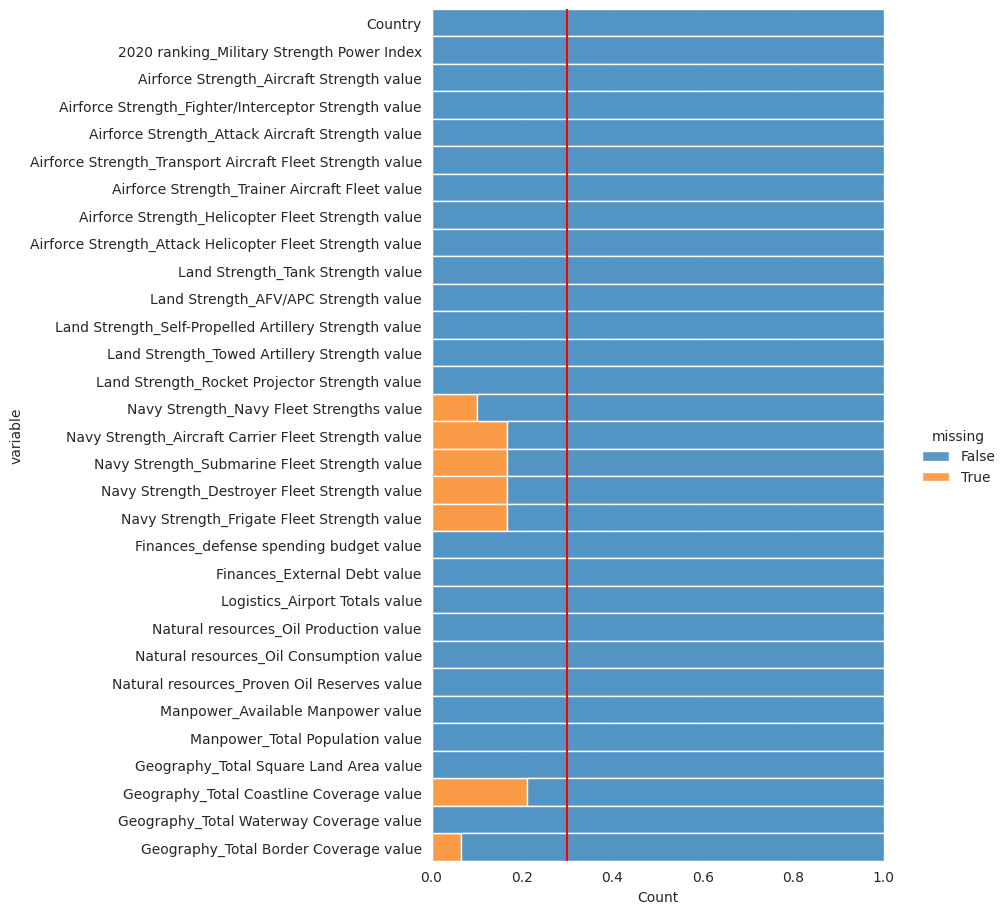

In [ ]:
plt.figure(figsize=(4,6))
sns.displot(
    data=df.isnull().melt(value_name='missing'),
    y='variable',
    hue='missing',
    multiple='fill',
    height=9.25
)
plt.axvline(0.3,color='r')
plt.show()

### Fix the datatypes

In [ ]:
#Fix the datatypes
df.select_dtypes('object')

,Country,Finances_defense spending budget value,Finances_External Debt value,Natural resources_Oil Production value,Natural resources_Oil Consumption value,Natural resources_Proven Oil Reserves value,Manpower_Available Manpower value,Manpower_Total Population value,Geography_Total Square Land Area value,Geography_Total Coastline Coverage value,Geography_Total Waterway Coverage value
0,Afghanistan,"12,00,00,00,000","2,84,00,00,000",0,5500,0,"1,43,25,743","3,49,40,837","6,52,230",0,1200
1,Albania,"25,00,00,000","9,50,50,00,000",16000,42500,"16,83,00,000","15,19,438","30,57,220",28748,362,41
2,Algeria,"13,00,00,00,000","6,26,00,00,000","13,06,000","3,25,000","12,20,00,00,000","2,07,41,263","4,16,57,488","23,81,741",998,0
3,Angola,"7,00,00,00,000","42,08,00,00,000","16,66,000",82300,"8,27,30,00,000","62,44,205","3,03,55,880","12,46,700",1600,1300
4,Argentina,"4,20,00,00,000","2,14,90,00,00,000","4,79,400","6,85,000","2,18,50,00,000","2,01,79,430","4,46,94,198","27,80,400",4989,11000
5,Armenia,"1,38,50,00,000","10,41,00,00,000",0,47500,0,"16,96,085","30,38,217",29743,NaN,0
6,Australia,"26,30,00,00,000","17,14,00,00,00,000","2,63,000","10,05,000","1,82,10,00,000","1,08,08,002","2,34,70,145","77,41,220",25760,2000
7,Austria,"3,38,00,00,000","6,30,80,00,00,000",14260,"2,15,000","4,30,00,000","40,17,691","87,93,370",83871,NaN,0
8,Azerbaijan,"2,80,50,00,000","17,41,00,00,000","7,89,300","1,80,000","7,00,00,00,000","50,42,346","1,00,46,516",86600,713,0
9,Bahrain,"1,41,50,00,000","52,15,00,00,000",45000,55000,"12,46,00,000","8,06,505","14,22,659",760,161,0


### convert str to float

In [ ]:
#convert str to float
import re
def convert(x):
    if x is not np.nan:
        x = str(x)
        y = re.findall('\d+', x)
        if '.' in x:
            return float(''.join(y[:-1]))
        else:
            return float(''.join(y))

In [ ]:
for i in df.select_dtypes('object').columns[1:]:
    df[i] = df[i].apply(convert)

In [ ]:
df.select_dtypes('object')

,Country
0,Afghanistan
1,Albania
2,Algeria
3,Angola
4,Argentina
5,Armenia
6,Australia
7,Austria
8,Azerbaijan
9,Bahrain


### Temel İstatistikler

Verinin yapısını, eksik değerleri ve temel istatistikleri inceliyoruz.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 31 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Country                                                    138 non-null    object 
 1   2020 ranking_Military Strength Power Index                 138 non-null    float64
 2   Airforce Strength_Aircraft Strength value                  138 non-null    int64  
 3   Airforce Strength_Fighter/Interceptor Strength value       138 non-null    int64  
 4   Airforce Strength_Attack Aircraft Strength value           138 non-null    int64  
 5   Airforce Strength_Transport Aircraft Fleet Strength value  138 non-null    int64  
 6   Airforce Strength_Trainer Aircraft Fleet value             138 non-null    int64  
 7   Airforce Strength_Helicopter Fleet Strength value          138 non-null    int64  
 8   Airforce S

In [ ]:
df.head()

,Country,2020 ranking_Military Strength Power Index,Airforce Strength_Aircraft Strength value,Airforce Strength_Fighter/Interceptor Strength value,Airforce Strength_Attack Aircraft Strength value,Airforce Strength_Transport Aircraft Fleet Strength value,Airforce Strength_Trainer Aircraft Fleet value,Airforce Strength_Helicopter Fleet Strength value,Airforce Strength_Attack Helicopter Fleet Strength value,Land Strength_Tank Strength value,Land Strength_AFV/APC Strength value,Land Strength_Self-Propelled Artillery Strength value,Land Strength_Towed Artillery Strength value,Land Strength_Rocket Projector Strength value,Navy Strength_Navy Fleet Strengths value,Navy Strength_Aircraft Carrier Fleet Strength value,Navy Strength_Submarine Fleet Strength value,Navy Strength_Destroyer Fleet Strength value,Navy Strength_Frigate Fleet Strength value,Finances_defense spending budget value,Finances_External Debt value,Logistics_Airport Totals value,Natural resources_Oil Production value,Natural resources_Oil Consumption value,Natural resources_Proven Oil Reserves value,Manpower_Available Manpower value,Manpower_Total Population value,Geography_Total Square Land Area value,Geography_Total Coastline Coverage value,Geography_Total Waterway Coverage value,Geography_Total Border Coverage value
0,Afghanistan,1.344,260,0,25,30,0,187,0,0,1062,0,176,50,0.000,0.000,0.000,0.000,0.000,12000000000.000,2840000000.000,43,0.000,5500.000,0.000,14325743.000,34940837.000,652230.000,0.000,1200.000,5987.000
1,Albania,2.314,19,0,0,0,0,19,0,0,467,0,0,0,38.000,0.000,0.000,0.000,0.000,250000000.000,9505000000.000,4,16000.000,42500.000,168300000.000,1519438.000,3057220.000,28748.000,362.000,41.000,691.000
2,Algeria,0.466,551,103,22,59,87,257,45,880,7361,320,240,316,201.000,0.000,6.000,0.000,5.000,13000000000.000,6260000000.000,157,1306000.000,325000.000,12200000000.000,20741263.000,41657488.000,2381741.000,998.000,0.000,6734.000
3,Angola,0.838,295,72,18,30,47,126,15,379,595,28,357,115,57.000,0.000,0.000,0.000,0.000,7000000000.000,42080000000.000,176,1666000.000,82300.000,8273000000.000,6244205.000,30355880.000,1246700.000,1600.000,1300.000,5369.000
4,Argentina,0.652,227,24,7,9,64,100,0,370,739,83,172,26,49.000,0.000,2.000,4.000,0.000,4200000000.000,214900000000.000,1138,479400.000,685000.000,2185000000.000,20179430.000,44694198.000,2780400.000,4989.000,11000.000,11968.000


### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
# Missing Values
from collections import defaultdict
dictt = defaultdict(list)
for i in df['Country'].values:
    if df[df['Country']==i][df.columns[1:]].isnull().any().any():
        for j in df.columns[1:]:
            if df.loc[df['Country']==i, j].isna().values:
                dictt[i].append(j)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
grouped = df.groupby('Country')
missing_values = grouped[df.columns[1:]].apply(lambda x: x.isnull().any())
dictt = missing_values.unstack().apply(lambda x: x.index[x].tolist()).to_dict()

### Hangi ülkede hangi bilgiler eksik

In [ ]:
#Hangi ülkede hangi bilgiler eksik
for i in df['Country'].values:
  if len(dictt[i])>0:
    print(f'***** {i} *****')
    print(dictt[i])
    print()

***** Armenia *****
['Navy Strength_Aircraft Carrier Fleet Strength value', 'Navy Strength_Submarine Fleet Strength value', 'Navy Strength_Destroyer Fleet Strength value', 'Navy Strength_Frigate Fleet Strength value', 'Geography_Total Coastline Coverage value']

***** Australia *****
['Geography_Total Border Coverage value']

***** Austria *****
['Navy Strength_Aircraft Carrier Fleet Strength value', 'Navy Strength_Submarine Fleet Strength value', 'Navy Strength_Destroyer Fleet Strength value', 'Navy Strength_Frigate Fleet Strength value', 'Geography_Total Coastline Coverage value']

***** Bahrain *****
['Geography_Total Border Coverage value']

***** Belarus *****
['Navy Strength_Aircraft Carrier Fleet Strength value', 'Navy Strength_Submarine Fleet Strength value', 'Navy Strength_Destroyer Fleet Strength value', 'Navy Strength_Frigate Fleet Strength value', 'Geography_Total Coastline Coverage value']

***** Bhutan *****
['Navy Strength_Aircraft Carrier Fleet Strength value', 'Navy St

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
df.isnull().sum()

Country                                                       0
2020 ranking_Military Strength Power Index                    0
Airforce Strength_Aircraft Strength value                     0
Airforce Strength_Fighter/Interceptor Strength value          0
Airforce Strength_Attack Aircraft Strength value              0
Airforce Strength_Transport Aircraft Fleet Strength value     0
Airforce Strength_Trainer Aircraft Fleet value                0
Airforce Strength_Helicopter Fleet Strength value             0
Airforce Strength_Attack Helicopter Fleet Strength value      0
Land Strength_Tank Strength value                             0
Land Strength_AFV/APC Strength value                          0
Land Strength_Self-Propelled Artillery Strength value         0
Land Strength_Towed Artillery Strength value                  0
Land Strength_Rocket Projector Strength value                 0
Navy Strength_Navy Fleet Strengths value                     14
Navy Strength_Aircraft Carrier Fleet Str

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
#Araştırma yap
#https://www.globalfirepower.com/navy-ships.php
#Navy Fleet Strengths value
df['Navy Strength_Navy Fleet Strengths value'] = df['Navy Strength_Navy Fleet Strengths value'].fillna(0)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
#Aircraft Carrier Fleet Strength value
#https://www.globalfirepower.com/navy-aircraft-carriers.php
df['Navy Strength_Aircraft Carrier Fleet Strength value'] = df['Navy Strength_Aircraft Carrier Fleet Strength value'].fillna(0)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
#Submarine Fleet Strength value
#https://www.globalfirepower.com/navy-submarines.php
df.loc[df['Country']=='South Korea', 'Navy Strength_Submarine Fleet Strength value'] = df.loc[df['Country']=='South Korea',
                                                            'Navy Strength_Submarine Fleet Strength value'].fillna(22)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
df['Navy Strength_Submarine Fleet Strength value'] = df['Navy Strength_Submarine Fleet Strength value'].fillna(0)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
#Destroyer Fleet Strength value
#https://www.globalfirepower.com/navy-destroyers.php
df.loc[df['Country']=='South Korea', 'Navy Strength_Destroyer Fleet Strength value'] = df.loc[df['Country']=='South Korea',
                                                            'Navy Strength_Destroyer Fleet Strength value'].fillna(12)
df['Navy Strength_Destroyer Fleet Strength value'] = df['Navy Strength_Destroyer Fleet Strength value'].fillna(0)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
#Frigate Fleet Strength value
#https://www.globalfirepower.com/navy-frigates.php
df.loc[df['Country']=='South Korea', 'Navy Strength_Frigate Fleet Strength value'] = df.loc[df['Country']=='South Korea',
                                                            'Navy Strength_Frigate Fleet Strength value'].fillna(18)
df['Navy Strength_Frigate Fleet Strength value'] = df['Navy Strength_Frigate Fleet Strength value'].fillna(0)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
#Total Coastline Coverage value
#https://www.globalfirepower.com/coastline-coverage.php
df['Geography_Total Coastline Coverage value'] = df['Geography_Total Coastline Coverage value'].fillna(0)

### Veri Ön İşleme

Veriyi temizliyoruz ve modele hazır hale getiriyoruz.

In [ ]:
#Total Border Coverage value
#https://www.globalfirepower.com/border-coverage.php
df['Geography_Total Border Coverage value'] = df['Geography_Total Border Coverage value'].fillna(0)
df.isnull().sum()

Country                                                      0
2020 ranking_Military Strength Power Index                   0
Airforce Strength_Aircraft Strength value                    0
Airforce Strength_Fighter/Interceptor Strength value         0
Airforce Strength_Attack Aircraft Strength value             0
Airforce Strength_Transport Aircraft Fleet Strength value    0
Airforce Strength_Trainer Aircraft Fleet value               0
Airforce Strength_Helicopter Fleet Strength value            0
Airforce Strength_Attack Helicopter Fleet Strength value     0
Land Strength_Tank Strength value                            0
Land Strength_AFV/APC Strength value                         0
Land Strength_Self-Propelled Artillery Strength value        0
Land Strength_Towed Artillery Strength value                 0
Land Strength_Rocket Projector Strength value                0
Navy Strength_Navy Fleet Strengths value                     0
Navy Strength_Aircraft Carrier Fleet Strength value    

### Drop the features that do not affect military power

In [ ]:
#Drop the features that do not affect military power
X = df.drop(['Geography_Total Square Land Area value', 'Geography_Total Coastline Coverage value',
             'Geography_Total Waterway Coverage value', 'Geography_Total Border Coverage value'], axis=1)
X.head()

,Country,2020 ranking_Military Strength Power Index,Airforce Strength_Aircraft Strength value,Airforce Strength_Fighter/Interceptor Strength value,Airforce Strength_Attack Aircraft Strength value,Airforce Strength_Transport Aircraft Fleet Strength value,Airforce Strength_Trainer Aircraft Fleet value,Airforce Strength_Helicopter Fleet Strength value,Airforce Strength_Attack Helicopter Fleet Strength value,Land Strength_Tank Strength value,Land Strength_AFV/APC Strength value,Land Strength_Self-Propelled Artillery Strength value,Land Strength_Towed Artillery Strength value,Land Strength_Rocket Projector Strength value,Navy Strength_Navy Fleet Strengths value,Navy Strength_Aircraft Carrier Fleet Strength value,Navy Strength_Submarine Fleet Strength value,Navy Strength_Destroyer Fleet Strength value,Navy Strength_Frigate Fleet Strength value,Finances_defense spending budget value,Finances_External Debt value,Logistics_Airport Totals value,Natural resources_Oil Production value,Natural resources_Oil Consumption value,Natural resources_Proven Oil Reserves value,Manpower_Available Manpower value,Manpower_Total Population value
0,Afghanistan,1.344,260,0,25,30,0,187,0,0,1062,0,176,50,0.000,0.000,0.000,0.000,0.000,12000000000.000,2840000000.000,43,0.000,5500.000,0.000,14325743.000,34940837.000
1,Albania,2.314,19,0,0,0,0,19,0,0,467,0,0,0,38.000,0.000,0.000,0.000,0.000,250000000.000,9505000000.000,4,16000.000,42500.000,168300000.000,1519438.000,3057220.000
2,Algeria,0.466,551,103,22,59,87,257,45,880,7361,320,240,316,201.000,0.000,6.000,0.000,5.000,13000000000.000,6260000000.000,157,1306000.000,325000.000,12200000000.000,20741263.000,41657488.000
3,Angola,0.838,295,72,18,30,47,126,15,379,595,28,357,115,57.000,0.000,0.000,0.000,0.000,7000000000.000,42080000000.000,176,1666000.000,82300.000,8273000000.000,6244205.000,30355880.000
4,Argentina,0.652,227,24,7,9,64,100,0,370,739,83,172,26,49.000,0.000,2.000,4.000,0.000,4200000000.000,214900000000.000,1138,479400.000,685000.000,2185000000.000,20179430.000,44694198.000


### Visualization

In [ ]:
#Visualization
import plotly.express as px

In [ ]:
fig = px.bar(X, x= X["Country"] , y = X["Airforce Strength_Aircraft Strength value"])
fig.show()

In [ ]:
fig = px.bar(X, x= X["Country"], y = X['Navy Strength_Navy Fleet Strengths value'])
fig.show()

In [ ]:
fig = px.bar(X, x= X["Country"], y = X['Land Strength_Tank Strength value'])
fig.show()

### Temel İstatistikler

Verinin yapısını, eksik değerleri ve temel istatistikleri inceliyoruz.

In [ ]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
2020 ranking_Military Strength Power Index,138.000,1.461,1.324,0.061,0.575,1.034,2.022,10.168
Airforce Strength_Aircraft Strength value,138.000,388.471,1231.982,0.000,33.000,111.000,290.250,13264.000
Airforce Strength_Fighter/Interceptor Strength value,138.000,81.565,230.325,0.000,0.000,17.000,60.500,2085.000
Airforce Strength_Attack Aircraft Strength value,138.000,25.761,94.528,0.000,0.000,0.000,15.750,742.000
Airforce Strength_Transport Aircraft Fleet Strength value,138.000,30.232,92.330,0.000,3.000,9.000,26.000,945.000
Airforce Strength_Trainer Aircraft Fleet value,138.000,82.833,240.804,0.000,4.250,26.000,79.250,2643.000
Airforce Strength_Helicopter Fleet Strength value,138.000,154.065,520.184,0.000,15.250,44.000,126.750,5768.000
Airforce Strength_Attack Helicopter Fleet Strength value,138.000,25.623,97.326,0.000,0.000,2.000,17.750,967.000
Land Strength_Tank Strength value,138.000,646.565,1515.464,0.000,19.250,153.000,436.250,12950.000
Land Strength_AFV/APC Strength value,138.000,2485.696,5410.546,0.000,250.250,734.500,2000.000,39253.000


### Korelasyon Analizi

Özellikler arasındaki ilişkiyi ısı haritası ile görselleştiriyoruz.

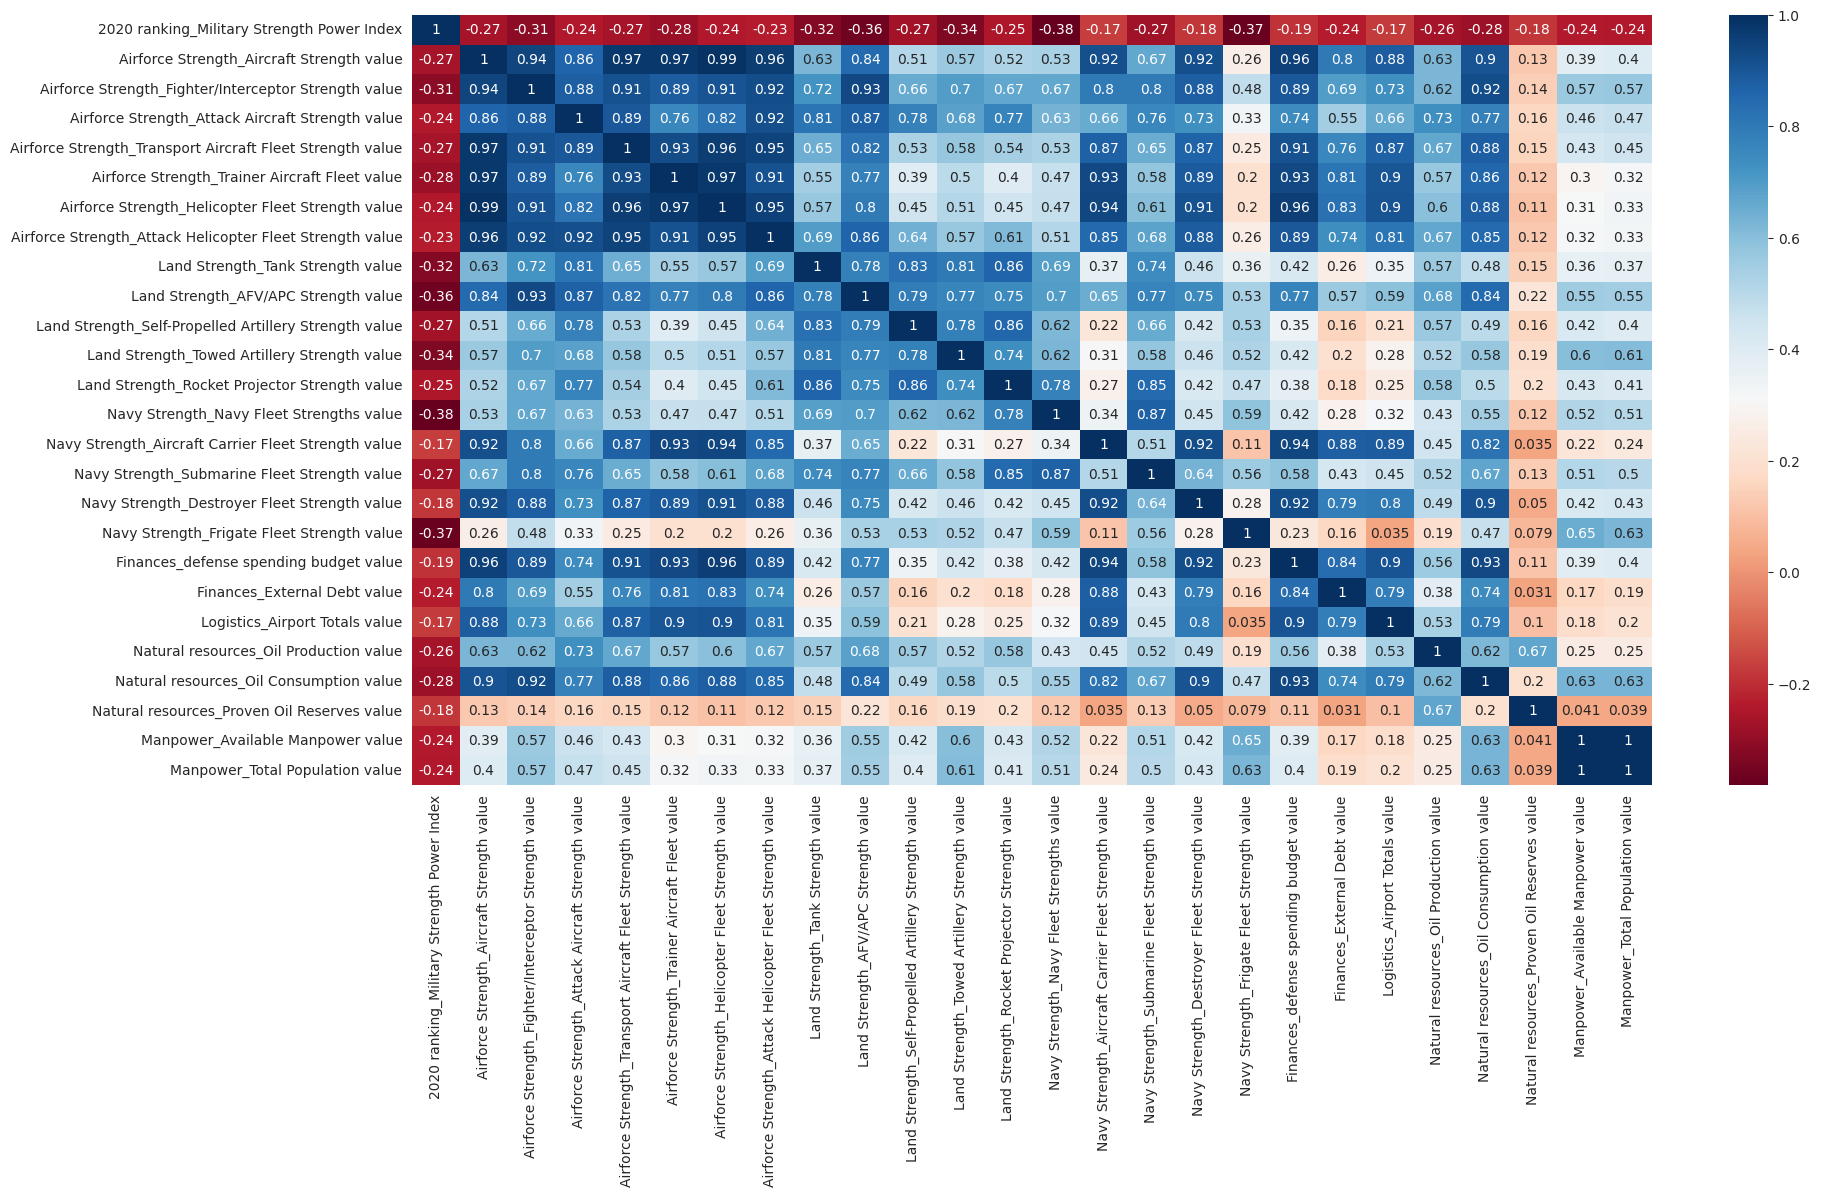

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(X.corr(), annot=True, cmap='RdBu');

### Data Preprocessig

In [ ]:
X = X.drop(["Country"], axis=1)

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

### Hopkins Testi sonucu 0-1 arasında 0 a ne kadar yakınsa veri seti kümeleme yapmaya o kadar uygundur.

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def hopkins_statistic(X, n_neighbors):
    # Veri setinin boyutunu alın
    n = X.shape[0]
    # K-en yakın komşuluk hesaplaması için komşu sayısını belirleyin
    k = int(np.sqrt(n / 2))

    # Rasgele noktalar seçin
    random_points = np.random.rand(n, X.shape[1])

    # Veri setindeki her bir nokta için en yakın komşuyu bulun
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='kd_tree').fit(X)
    random_nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='kd_tree').fit(random_points)

    # Her bir nokta için en yakın komşuların mesafelerini alın
    d1, _ = nbrs.kneighbors(X)
    d2, _ = random_nbrs.kneighbors(X)

    # Hopkins İstatistiğini hesaplayın
    # İstatistik değeri 0.5'ten küçükse, veri seti kümelenebilir kabul edilir
    hopkins_stat = np.sum(d1) / (np.sum(d1) + np.sum(d2))
    return hopkins_stat

# Hopkins İstatistiğini hesaplama
hopkins_score = hopkins_statistic(X_scaled, n_neighbors=5)
print("Hopkins Statistic:", hopkins_score)

Hopkins Statistic: 0.2539407178016463


### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |
| `yellowbrick` | Yardımcı kütüphane |


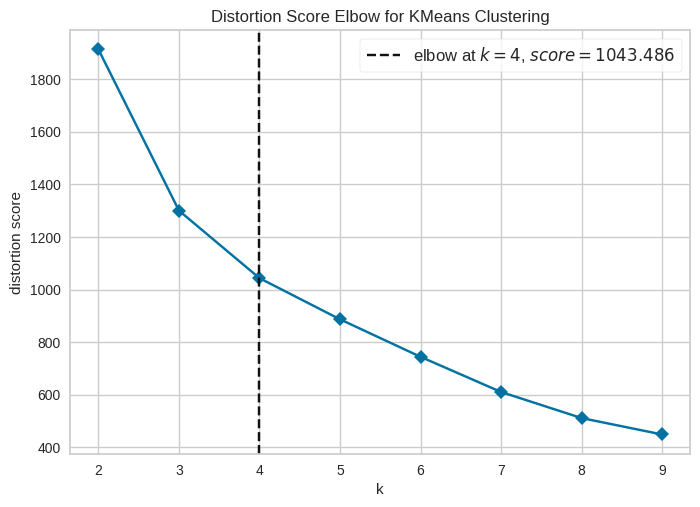

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2,10), metric='distortion', timings=False)

visualizer.fit(X_scaled)
visualizer.show()

### Model Eğitimi

Modeli eğitim verisi üzerinde eğitip test verisi üzerinde değerlendiriyoruz.

In [ ]:
#Silhouette Analysis
from sklearn.metrics import silhouette_score
range_n_clusters = range(2,10)
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X_scaled)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")

For n_clusters=2, the silhouette score is 0.8633858204107134
For n_clusters=3, the silhouette score is 0.8177570041876348
For n_clusters=4, the silhouette score is 0.4875152444741244
For n_clusters=5, the silhouette score is 0.5160682621481072
For n_clusters=6, the silhouette score is 0.5112276566110376
For n_clusters=7, the silhouette score is 0.4766296059298667
For n_clusters=8, the silhouette score is 0.4669195312137166
For n_clusters=9, the silhouette score is 0.41240380417202366


### Model Building

In [ ]:
model = KMeans(n_clusters=4, random_state=42)
model.fit_predict(X_scaled)

array([0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0,
       3, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 3, 0, 0, 3,
       0, 3, 0, 0, 0, 3, 3, 3, 3, 0, 3, 3, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 3,
       0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0,
       3, 0, 3, 0, 0, 0, 0, 0, 3, 3, 0, 0, 3, 0, 3, 0, 0, 3, 3, 3, 1, 0,
       0, 3, 3, 0, 0, 0], dtype=int32)

### Evaluate

In [ ]:
df["predicted_clusters_kmeans"] = model.labels_
X_scaled['predicted_clusters_kmeans'] = model.labels_
df[['Country', 'predicted_clusters_kmeans']]

,Country,predicted_clusters_kmeans
0,Afghanistan,0
1,Albania,0
2,Algeria,3
3,Angola,0
4,Argentina,0
5,Armenia,0
6,Australia,0
7,Austria,0
8,Azerbaijan,0
9,Bahrain,0


In [ ]:
fig = px.scatter_3d(x=df["Airforce Strength_Aircraft Strength value"],
                   y=df["Finances_defense spending budget value"],
                   z=df["Finances_External Debt value"],
                   color=df.predicted_clusters_kmeans,
                   labels = {"x": "Airforce Strength_Aircraft Strength value",
                             "y": "Finances_defense spending budget value",
                             "z": "Finances_External Debt value"},
                   hover_name=df["Country"])
fig.show()

### Görselleştirme

Veriyi grafik ile inceliyoruz.

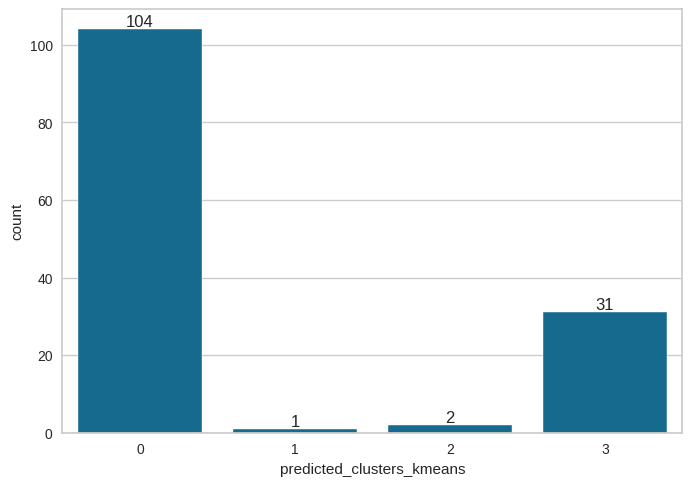

In [ ]:
ax = sns.countplot(data=df, x='predicted_clusters_kmeans')
ax.bar_label(ax.containers[0]);

In [ ]:
df[df.predicted_clusters_kmeans == 0]['Country']

0                           Afghanistan
1                               Albania
3                                Angola
4                             Argentina
5                               Armenia
6                             Australia
7                               Austria
8                            Azerbaijan
9                               Bahrain
10                           Bangladesh
11                              Belarus
12                              Belgium
13                               Bhutan
14                              Bolivia
15               Bosnia and Herzegovina
16                             Botswana
18                             Bulgaria
19                         Burkina Faso
20                             Cambodia
21                             Cameroon
23             Central African Republic
24                                 Chad
25                                Chile
28                              Croatia
29                                 Cuba


![image.png](attachment:image.png)

In [ ]:
df[df.predicted_clusters_kmeans == 1]['Country']


130    United States
Name: Country, dtype: object

In [ ]:
df[df.predicted_clusters_kmeans == 2]['Country']


26      China
101    Russia
Name: Country, dtype: object

In [ ]:
df[df.predicted_clusters_kmeans == 3]['Country']

2                   Algeria
17                   Brazil
22                   Canada
27                 Colombia
35                    Egypt
40                   France
43                  Germany
45                   Greece
49                    India
50                Indonesia
51                     Iran
52                     Iraq
54                   Israel
55                    Italy
57                    Japan
73                   Mexico
79                  Myanmar
87              North Korea
91                 Pakistan
102            Saudi Arabia
110             South Korea
112                   Spain
118                   Syria
119                  Taiwan
122                Thailand
124                  Turkey
127                 Ukraine
128    United Arab Emirates
129          United Kingdom
133               Venezuela
134                 Vietnam
Name: Country, dtype: object

### Dendogram

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `scipy` | Bilimsel hesaplama |


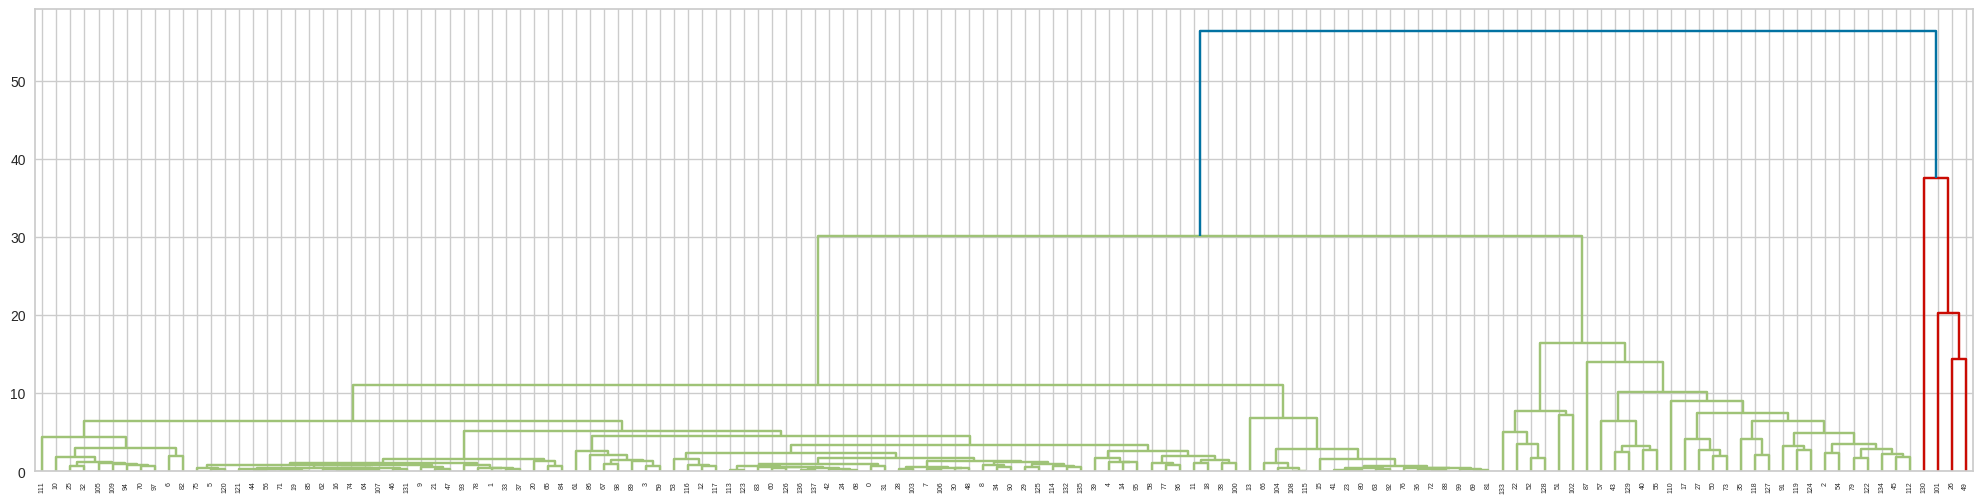

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
data=linkage(X_scaled, method='ward', metric='euclidean')
plt.figure(figsize=(25, 6))
dendrogram(data)
plt.show()

### PCA-Principal Component Analyse

### calculate cov matris

In [ ]:
# calculate cov matris
cov_matris = np.cov(X_scaled.T)

# eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matris)

#sum of variance
total_variance = np.sum(eigenvalues)

print("Eigenvalues and Variance Contribution:")
for i, value in enumerate(eigenvalues):
    variance_contribution = value / total_variance
    print("Bileşen {}: {:.4f} (%{:.2f} Toplam Varyans Katkısı)".format(i+1, value, variance_contribution*100))

Eigenvalues and Variance Contribution:
Bileşen 1: 16.1800 (%58.23 Toplam Varyans Katkısı)
Bileşen 2: 4.0106 (%14.43 Toplam Varyans Katkısı)
Bileşen 3: 1.8206 (%6.55 Toplam Varyans Katkısı)
Bileşen 4: 1.6906 (%6.08 Toplam Varyans Katkısı)
Bileşen 5: 1.1169 (%4.02 Toplam Varyans Katkısı)
Bileşen 6: 0.6745 (%2.43 Toplam Varyans Katkısı)
Bileşen 7: 0.6282 (%2.26 Toplam Varyans Katkısı)
Bileşen 8: 0.4635 (%1.67 Toplam Varyans Katkısı)
Bileşen 9: 0.2312 (%0.83 Toplam Varyans Katkısı)
Bileşen 10: 0.1997 (%0.72 Toplam Varyans Katkısı)
Bileşen 11: 0.1468 (%0.53 Toplam Varyans Katkısı)
Bileşen 12: 0.1359 (%0.49 Toplam Varyans Katkısı)
Bileşen 13: 0.1100 (%0.40 Toplam Varyans Katkısı)
Bileşen 14: 0.0921 (%0.33 Toplam Varyans Katkısı)
Bileşen 15: 0.0845 (%0.30 Toplam Varyans Katkısı)
Bileşen 16: 0.0488 (%0.18 Toplam Varyans Katkısı)
Bileşen 17: 0.0357 (%0.13 Toplam Varyans Katkısı)
Bileşen 18: 0.0295 (%0.11 Toplam Varyans Katkısı)
Bileşen 19: 0.0257 (%0.09 Toplam Varyans Katkısı)
Bileşen 20: 0.022

### PCA' da beş bileşenli yapı (eigen value 1 den büyük değerler için) varyansın %90 dan fazlasını açıklıyor

In [ ]:
#PCA' da beş bileşenli yapı (eigen value 1 den büyük değerler için) varyansın %90 dan fazlasını açıklıyor
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
data_pca = pca.fit_transform(X_scaled)

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |
| `yellowbrick` | Yardımcı kütüphane |


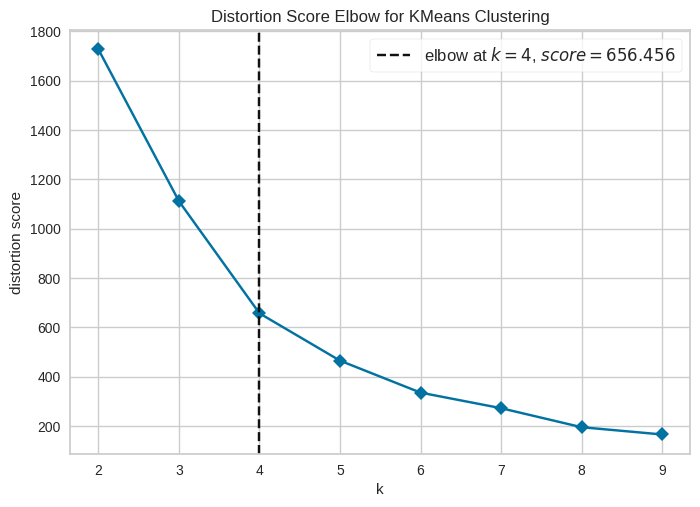

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2,10), metric='distortion', timings=False)

visualizer.fit(data_pca)
visualizer.show()

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)
kmeans.fit(data_pca)

KMeans(n_clusters=4)

In [ ]:
df["predicted_clusters_kmeans_2"] = kmeans.labels_
df[['Country', 'predicted_clusters_kmeans_2']]

,Country,predicted_clusters_kmeans_2
0,Afghanistan,0
1,Albania,0
2,Algeria,3
3,Angola,0
4,Argentina,0
5,Armenia,0
6,Australia,0
7,Austria,0
8,Azerbaijan,0
9,Bahrain,0


### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `seaborn` | İstatistiksel grafikler |


<Axes: xlabel='predicted_clusters_kmeans_2', ylabel='count'>

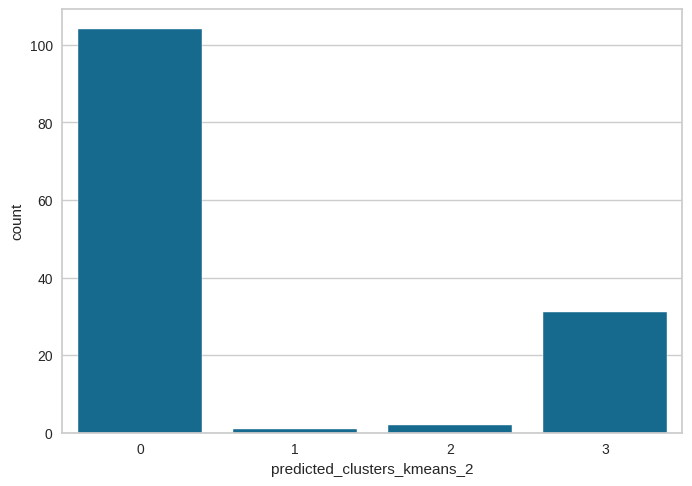

In [ ]:
import seaborn as sns
sns.countplot(x=df['predicted_clusters_kmeans_2'])

---

<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ-5B2C1E?style=flat-square&logo=python&logoColor=white" alt="ECS"/>

**Dr. Murat Altun** · Veri Bilimi ve Yapay Zeka Eğitmeni

<a href="https://yapayzekaokulum.com">Yapay Zeka Okulum</a> ·
<a href="https://gencyz.com">GençYZ</a> ·
<a href="https://yz-araclari.com">YZ Araçları</a> ·
<a href="https://akademikyz.com">ScholarAI</a> ·
<a href="https://drmurataltun.github.io">Kişisel Site</a>

<a href="https://drmurataltun.github.io/VB-YZ-90/">drmurataltun.github.io/VB-YZ-90</a>

---

*Bu materyal ECS Veri Bilimi ve Yapay Zeka Uzmanlığı Programı için hazırlanmıştır.*

© 2026 Dr. Murat Altun. Tüm hakları saklıdır.

</div>